## **SUPERVISED LEARNING**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load the dataset
df = pd.read_csv('winequality-red.csv')
df.head(5)  # Show the first few rows
print(f'Number of duplicates: {df.duplicated().sum()}')
print(f'Number of missing values: {df.isna().sum().sum()}')

Number of duplicates: 240
Number of missing values: 0


In [3]:
# Rename columns for consistency
df.rename(columns={'fixed acidity': 'FixedAcidity', 'volatile acidity': 'VolatileAcidity', 'citric acid': 'CitricAcid', 'residual sugar': 'ResidualSugar'}, inplace=True)

# Splitting the dataset into features and target
X = df.drop('quality', axis=1)  # Features
y = df['quality']  # Target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Applying KNN Classifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = knn_model.predict(X_test_scaled)

# Model evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.546875
Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.59      0.68      0.63       130
           6       0.51      0.55      0.53       132
           7       0.54      0.36      0.43        42
           8       0.00      0.00      0.00         5

    accuracy                           0.55       320
   macro avg       0.27      0.26      0.26       320
weighted avg       0.52      0.55      0.53       320



c:\Users\camil\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\camil\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\camil\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [4]:
# 3. Encodage des variables catégoriques (si besoin, ici tout est numérique)
# Identifying the optimal number of clusters with the elbow method
sse = []  # Within-Cluster Sum of Squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    sse.append(kmeans.inertia_)

# Display of elbow method
plt.plot(range(1, 11), sse, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('sse')
plt.show()


NameError: name 'KMeans' is not defined

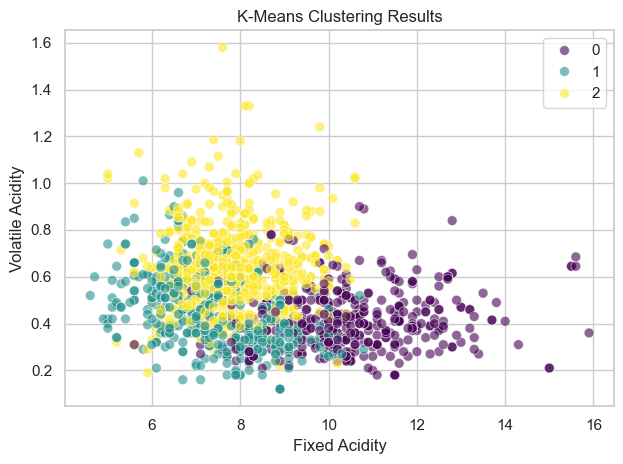

In [80]:
kmeans = KMeans(n_clusters=3, random_state=42)  # Use of 3 clusters
clusters = kmeans.fit_predict(scaled_features)

# Cluster visualization
sns.scatterplot(x=df['FixedAcidity'], y=df['VolatileAcidity'], hue=clusters, palette='viridis', s=50, alpha=0.6)
plt.title('K-Means Clustering Results')
plt.xlabel('Fixed Acidity')
plt.ylabel('Volatile Acidity')
plt.show()




## **UNSUPERVISED LEARNING**

In [81]:
##Loading libraries :

import numpy as np                
import pandas as pd               
import matplotlib.pyplot as plt   
import seaborn as sns             
%matplotlib inline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as shc
from sklearn.cluster import AgglomerativeClustering
import warnings
warnings.filterwarnings('ignore')


In [82]:
df = pd.read_csv('Mall_Customers.csv')
df.head(5)
print(f'Number of duplicates : {df.duplicated().sum()}')
print(f'Number of missing values : {sum(df.isna().sum())}')
df.rename(columns={'Annual Income (k$)': 'Income(k$/yr)', 'Spending Score (1-100)': 'SpendScore(1-100)'}, inplace=True)
df = df.drop(columns=['CustomerID'])


Number of duplicates : 0
Number of missing values : 0


In [83]:
##Data preparation and standardization :

X = df[['Income(k$/yr)', 'SpendScore(1-100)']]
scaler = StandardScaler()
X_kmeans = scaler.fit_transform(X)


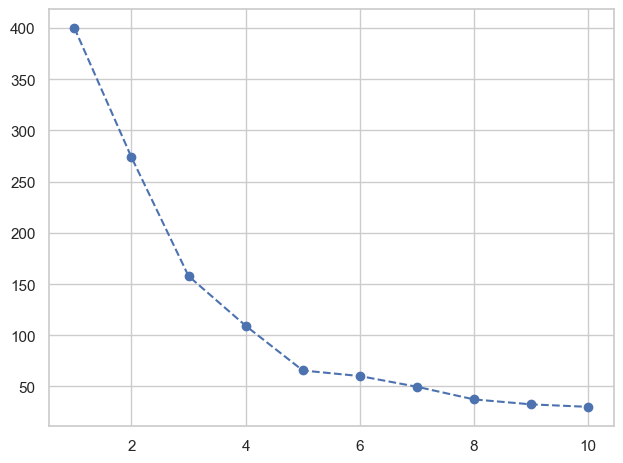

In [84]:
##Elbow method for determining the number of clusters :

sse = []
for cluster in range(1, 11):
    kmeans = KMeans(n_clusters=cluster, init='k-means++', random_state=42)
    kmeans.fit(X_kmeans)
    sse.append(kmeans.inertia_)

plt.plot(range(1, 11), sse, 'o--')


<Axes: xlabel='SpendScore(1-100)', ylabel='Income(k$/yr)'>

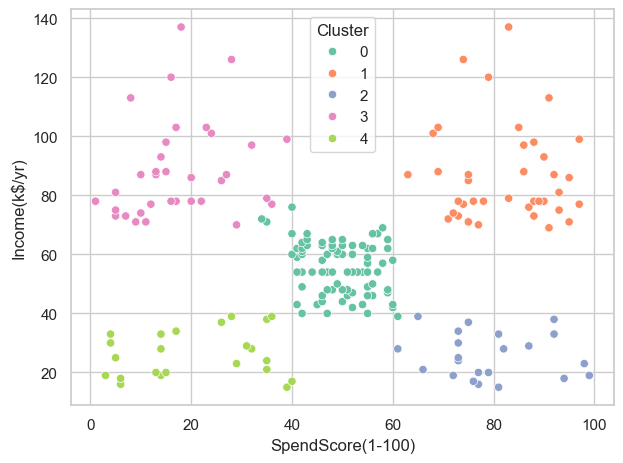

In [85]:
##KMeans with 5 clusters and visualization :

clusters = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = clusters.fit_predict(X_kmeans)
df['Cluster'] = y_kmeans
sns.scatterplot(data=df, x='SpendScore(1-100)', y='Income(k$/yr)', hue='Cluster', palette="Set2")


<Axes: xlabel='SpendScore(1-100)', ylabel='Income(k$/yr)'>

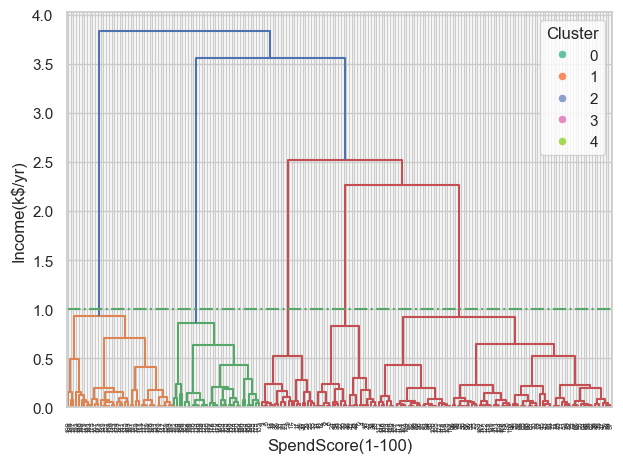

In [86]:
##Hierarchical analysis (Dendrogram) :

X_Hierar = norm.fit_transform(X)
dendrogram = shc.dendrogram(shc.linkage(X_Hierar, method='ward'))
plt.axhline(y=1, color='g', linestyle='dashdot')
clusters = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = clusters.fit_predict(X_Hierar)
df['Cluster'] = y_kmeans
sns.scatterplot(data=df, x='SpendScore(1-100)', y='Income(k$/yr)', hue='Cluster', palette="Set2")
